## What are the most demanded skills for top 3 most popular data roles?

In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns

ds = load_dataset("lukebarousse/data_jobs")                                 #loading the dataset
df = ds['train'].to_pandas()                                                #converting to dataframe type
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])               # job_posted_date cleanup

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
    
df['job_skills'] = df['job_skills'].apply(clean_list)                       # job_skill cleanup

In [2]:
df_ind = df[df['job_country'] == 'India']                                   # Filter Data for India

df_skills = df_ind.explode('job_skills')

df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name = 'skill_count')
df_skills_count.sort_values(by = 'skill_count', ascending = False, inplace = True)

df_skills_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
389,esquisse,Data Scientist,1
887,node.js,Senior Data Analyst,1
753,matlab,Cloud Engineer,1
411,fastapi,Cloud Engineer,1


In [3]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])                                          # Keeps only top 3 in the list (based on the order they appear in DataFrame)
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

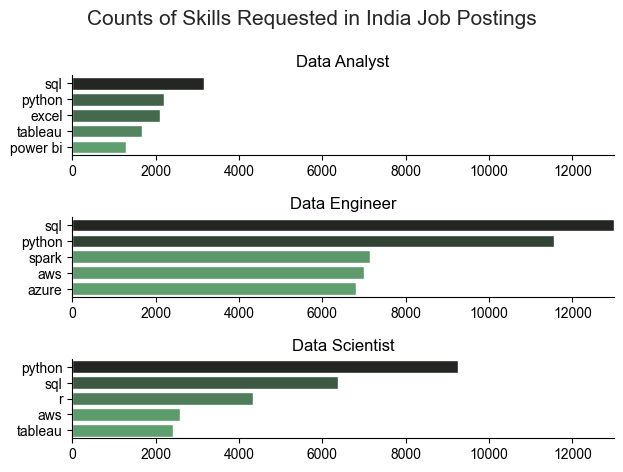

In [14]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    sns.set_theme(style= 'ticks')
    sns.barplot(data = df_plot, x = 'skill_count', y = 'job_skills', ax = ax[i], hue = 'skill_count', palette = 'dark:g_r', legend = False)
    sns.despine()
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 13000)
fig.suptitle('Counts of Skills Requested in India Job Postings', fontsize=15)
fig.tight_layout()
plt.show()
    

In [5]:
df_jobs_total = df_ind['job_title_short'].value_counts().reset_index(name = 'total_jobs')
df_jobs_total

,job_title_short,total_jobs
0,Data Engineer,19062
1,Data Scientist,13279
2,Data Analyst,6121
3,Senior Data Engineer,4353
4,Senior Data Scientist,2486
5,Business Analyst,1887
6,Software Engineer,1795
7,Senior Data Analyst,1083
8,Machine Learning Engineer,671
9,Cloud Engineer,351


In [6]:
df_skills_percent = pd.merge(df_skills_count, df_jobs_total, how= 'left', on = 'job_title_short')
df_skills_percent['skill_percent'] = 100 * (df_skills_percent['skill_count'] / df_skills_percent['total_jobs'])
df_skills_percent

,job_skills,job_title_short,skill_count,total_jobs,skill_percent
0,sql,Data Engineer,12993,19062,68.161788
1,python,Data Engineer,11568,19062,60.686182
2,python,Data Scientist,9248,13279,69.643798
3,spark,Data Engineer,7157,19062,37.545903
4,aws,Data Engineer,6993,19062,36.685552
...,...,...,...,...,...
1684,esquisse,Data Scientist,1,13279,0.007531
1685,node.js,Senior Data Analyst,1,1083,0.092336
1686,matlab,Cloud Engineer,1,351,0.284900
1687,fastapi,Cloud Engineer,1,351,0.284900


In [7]:
job_titles = df_skills_percent['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])                                          # Keeps only top 3 in the list (based on the order they appear in DataFrame)
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

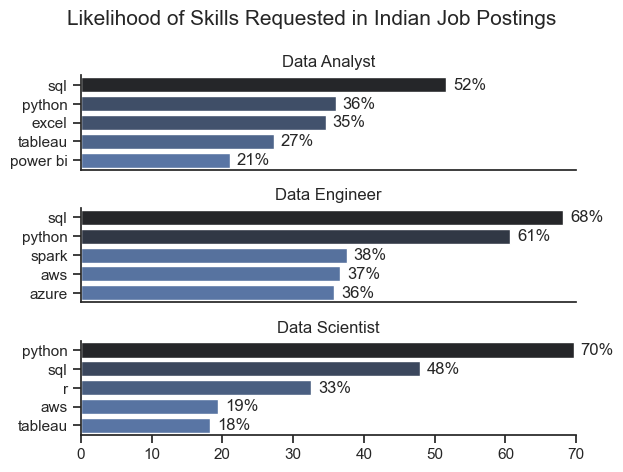

In [15]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_percent[df_skills_percent['job_title_short'] == job_title].head(5)
    sns.set_theme(style= 'ticks')
    sns.barplot(data = df_plot, x = 'skill_percent', y = 'job_skills', ax = ax[i], hue = 'skill_percent', palette = 'dark:b_r', legend = False)
    sns.despine()
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,70)
    
    for n,v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1,n,f'{v:.0f}%',va ='center')
        
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
        
fig.suptitle('Likelihood of Skills Requested in Indian Job Postings', fontsize=15)
fig.tight_layout()
plt.show()
    